In [1]:
import cv2
import h5py
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation
from PIL import Image

import numpy as np
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection, LineCollection

from dataclasses import dataclass
from typing import Optional

from baseline import Baseline 
from MirrorFeatureExtractor.mirror_feature_extractor import (
    extract_glcm_features,
    extract_lbp_features,
    extract_edge_features
)

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor

from DetectionMetrics.detection_metrics import DetectionMetrics

from baseline import visualization_mirrors

from tools import mark_mirrors_on_img

In [6]:
def get_features_and_info(file_path):
    with h5py.File(file_path, "r") as f:
        features = f["feature_matrix"][:]        # (n_images, 249, 11)
        valid = f["valid_mask"][:]               # (n_images, 249)
        names = [n.decode() for n in f["features_name"][:]]
        filenames = [n.decode() for n in f["image_filenames"][:]]
        
        # metadata
        print(f"Created: {f.attrs['created_at']}")
        print(f"Shape:   {features.shape}  →  {len(filenames)} images × {features.shape[1]} mirrors × {len(names)} features")

        return features, valid, names, filenames
        

In [18]:
BASELINE_FILE_UBUNTU = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/baseline/baseline_webcam_features_2.h5"
feat, valid, names, file_names = get_features_and_info(BASELINE_FILE_UBUNTU)

Created: 2026-05-26T14:01:46.114445+00:00
Shape:   (69, 249, 11)  →  69 images × 249 mirrors × 11 features


In [19]:
feat.shape

(69, 249, 11)

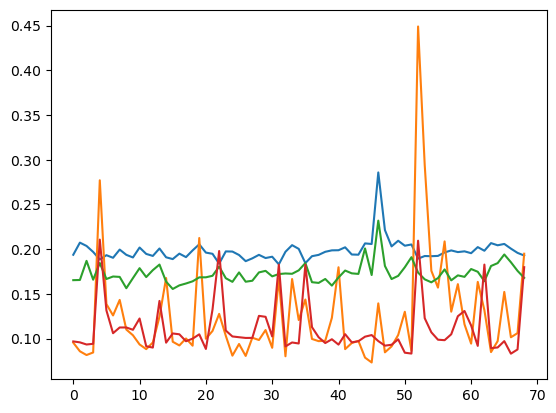

In [24]:
plt.plot(feat[:, 15, 2])
plt.plot(feat[:, 150, 2])
plt.plot(feat[:, 50, 2])
plt.plot(feat[:, 200, 2])

In [ ]:
# Indeksy do usunięcia
indices_to_remove = [46, 65, 66]

# Usunięcie elementów z pierwszego wymiaru
features_filtered = np.delete(features, indices_to_remove, axis=0)

In [12]:
print(file_names[:5])
print(names)

['image_2023-04-18_1500.jpg', 'image_2023-04-18_1600.jpg', 'image_2023-04-18_1700.jpg', 'image_2023-04-18_1800.jpg', 'image_2023-04-19_1000.jpg']
['glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'lbp_entropy', 'lbp_uniformity', 'sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']


## Mark mirrors in image

In [2]:
img_path_4 = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/webcam_img/image_2023-04-23_1400.jpg"

img = cv2.imread(str(img_path_4))
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/calibration/points_WebCam.json")

In [3]:
p_list = []
for m_id in range(249):
    p_list.append(mirror_extractor.get_point_coords(m_id))

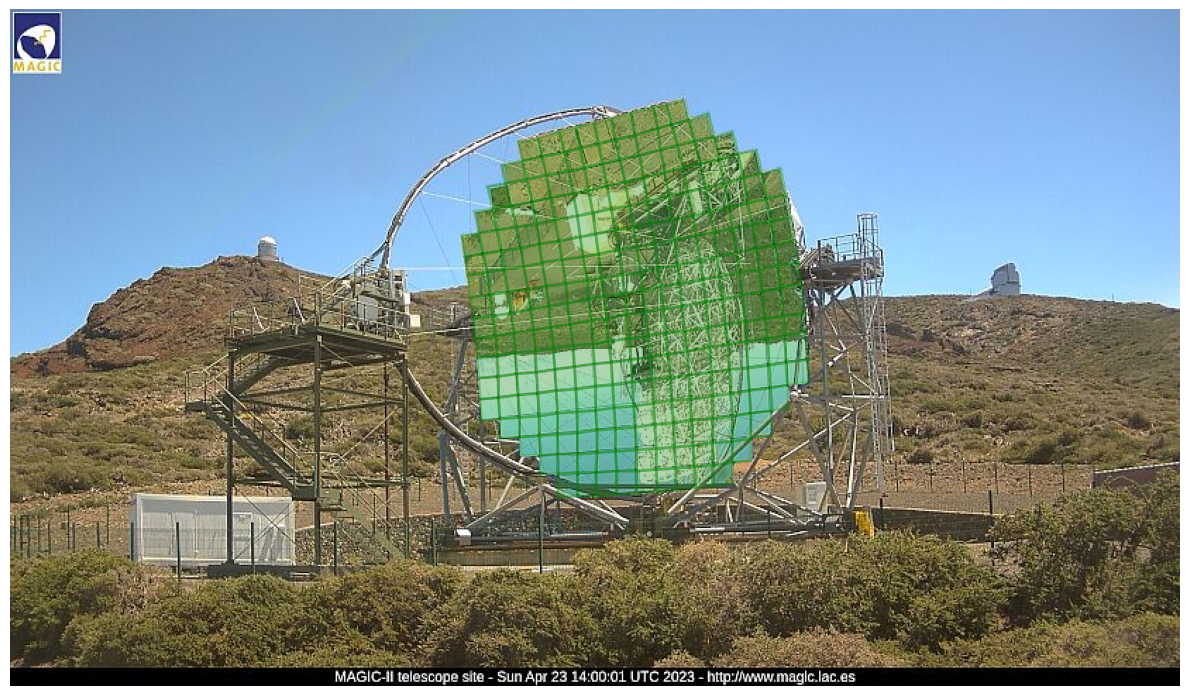

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mark_mirrors_on_img(img_path_4, p_list, "green", ax)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("hand_segmentation_webcam.png")

### IR Camera

In [11]:
mirror_extractor_ircam = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/points_IRCam.json")
img_path_2 = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/2026/05/07/IRCamM1T_20260507_124652.jpg"

In [12]:
p_list = []
for m_id in range(249):
    p_list.append(mirror_extractor_ircam.get_point_coords(m_id))

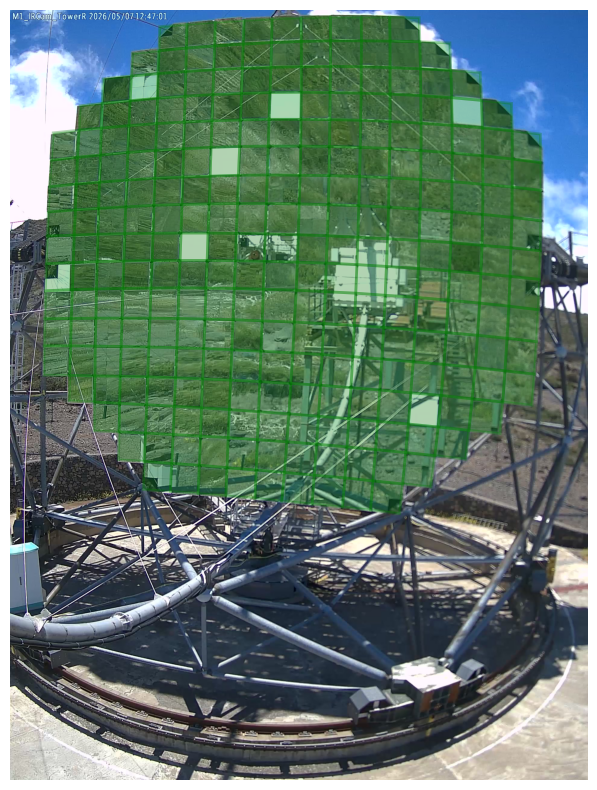

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mark_mirrors_on_img(img_path_2, p_list, "green", ax)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("hand_segmentation_ircam.png")